**Task 1: News Topic Classifier Using BERT**




**Problem Statement & Objective:**

Fine-tune bert-base-uncased to classify AG News headlines into four categories:

0 = World

1 = Sports

2 = Business

3 = Sci/Tech

**Dataset:**

AG News Dataset from Hugging Face Datasets

**Evaluation:**

Accuracy,

F1-score,


**Install Libraries**

In [ ]:
!pip install -q datasets transformers evaluate accelerate scikit-learn matplotlib seaborn streamlit

**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import (
    BertTokenizerFast,
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
    AutoModelForSequenceClassification
)

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

**Load Dataset**

In [ ]:
dataset = load_dataset("/content/ag_news")

dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 7600
    })
})

**Inspect Dataset**

In [ ]:
label_names = ["World", "Sports", "Business", "Sci/Tech"]

print(dataset["train"][0])
print(dataset["test"][0])

{'label': 3, 'title': 'Wall St. Bears Claw Back Into the Black (Reuters)', 'description': "Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again."}
{'label': 3, 'title': 'Fears for T N pension after talks', 'description': "Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul."}


**Convert to DataFrame for Visualization**

In [ ]:
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

train_df.head()

,label,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


**Label Distribution**

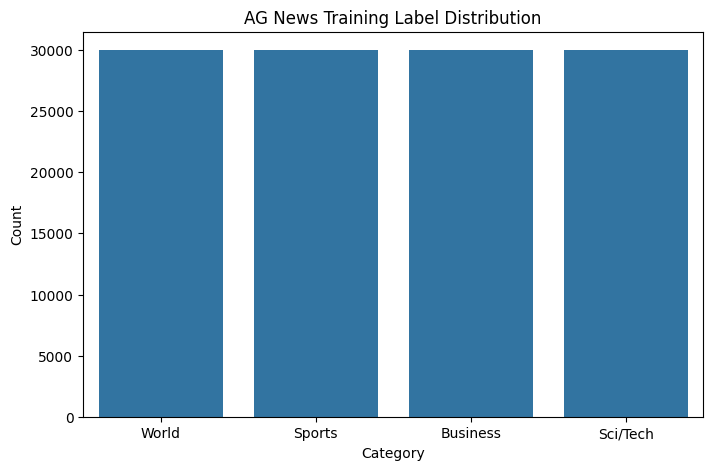

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x=train_df["label"])
plt.xticks(ticks=[0,1,2,3], labels=label_names)
plt.title("AG News Training Label Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

**Use Smaller Dataset for Faster Training**

In [ ]:
small_train = dataset["train"].shuffle(seed=42).select(range(10000))
small_test = dataset["test"].shuffle(seed=42).select(range(2000))

small_train, small_test

(Dataset({
     features: ['label', 'title', 'description'],
     num_rows: 10000
 }),
 Dataset({
     features: ['label', 'title', 'description'],
     num_rows: 2000
 }))

**Tokenization**

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import sys

def tokenize_function(examples):
    # Combine title and description
    combined_texts = [
        str(title) + " " + str(description)
        for title, description in zip(examples["title"], examples["description"])
    ]
    result = tokenizer(
        combined_texts,
        padding="max_length",
        truncation=True,
        max_length=128
    )
    # AG News labels are 1-4. Subtract 1 to make them 0-3 for BERT.
    result["label"] = [int(l) - 1 for l in examples["label"]]
    return result

# Map the tokenization and label shift
tokenized_train = small_train.map(tokenize_function, batched=True)
tokenized_test = small_test.map(tokenize_function, batched=True)

tokenized_train = tokenized_train.remove_columns(["title", "description"])
tokenized_test = tokenized_test.remove_columns(["title", "description"])

# Fix for 'VideoReader' ImportError: Disable torchvision interaction in datasets
if "torchvision" in sys.modules:
    del sys.modules["torchvision"]

# Set format to torch
tokenized_train.set_format("torch")
tokenized_test.set_format("torch")

# Verification of unique labels
print("Unique Adjusted Train labels:", sorted(list(set(tokenized_train["label"].tolist() if hasattr(tokenized_train["label"], 'tolist') else tokenized_train["label"][:].tolist()))))
print("Unique Adjusted Test labels:", sorted(list(set(tokenized_test["label"].tolist() if hasattr(tokenized_test["label"], 'tolist') else tokenized_test["label"][:].tolist()))))

Unique Adjusted Train labels: [0, 1, 2, 3]
Unique Adjusted Test labels: [0, 1, 2, 3]


**Prepare Dataset Format**

In [ ]:
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_test = tokenized_test.rename_column("label", "labels")

tokenized_train.set_format("torch")
tokenized_test.set_format("torch")

**Load BERT Model**

In [ ]:

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=4
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


**Evaluation Metrics**

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="weighted")

    return {
        "accuracy": accuracy,
        "f1": f1
    }

**Training Arguments**

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./logs",
    report_to="none"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


**Trainer**

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics
)

In [ ]:
import sys

if "torchvision" in sys.modules:
    del sys.modules["torchvision"]

if "torchvision.io" in sys.modules:
    del sys.modules["torchvision.io"]

**Train Model**

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.323532,0.323088,0.902000,0.901627
2,0.198707,0.342447,0.916500,0.916503


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2500, training_loss=0.29582403869628904, metrics={'train_runtime': 604.9469, 'train_samples_per_second': 33.061, 'train_steps_per_second': 4.133, 'total_flos': 1315578900480000.0, 'train_loss': 0.29582403869628904, 'epoch': 2.0})

**Evaluation metrics**

In [ ]:
results = trainer.evaluate()

results

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.198707,0.342447,2,0.916500,0.916503


{'eval_loss': 0.3424474000930786,
 'eval_accuracy': 0.9165,
 'eval_f1': 0.916502955598156}

**Predictions**

In [ ]:
predictions = trainer.predict(tokenized_test)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

**Accuracy and F1 Score**

In [ ]:
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("F1 Score:", f1)

Accuracy: 0.9165
F1 Score: 0.916502955598156


**Test Custom Headlines**

In [ ]:
def predict_news_topic(text):
    # Re-define label names in case they were lost in the session
    labels = ["World", "Sports", "Business", "Sci/Tech"]

    # Ensure tokenizer is defined locally
    local_tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
    inputs = local_tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )

    # Move inputs to the same device as model
    inputs = {key: value.to(model.device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        predicted_class = torch.argmax(probs, dim=1).item()
        confidence = probs[0][predicted_class].item()

    return labels[predicted_class], confidence

headline = "FIFA World Cup kick starts on june 12, 2026"
category, confidence = predict_news_topic(headline)

print("Headline:", headline)
print("Predicted Category:", category)
print("Confidence:", f"{confidence:.4f}")

Headline: FIFA World Cup kick starts on june 12, 2026
Predicted Category: Sports
Confidence: 0.9932


**Save model**

In [ ]:
model.save_pretrained("saved_model")
tokenizer.save_pretrained("saved_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('saved_model/tokenizer_config.json', 'saved_model/tokenizer.json')

**Download Saved Model**

In [ ]:
import shutil

shutil.make_archive("bert_agnews_saved_model", "zip", "saved_model")

'/content/bert_agnews_saved_model.zip'

In [28]:
from google.colab import files

files.download("bert_agnews_saved_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final Conclusion

This notebook demonstrates the process of fine-tuning a BERT-based model for news topic classification. We loaded the AG News dataset, preprocessed it using tokenization, trained a `BertForSequenceClassification` model, and evaluated its performance.

 The model achieved a high accuracy and F1-score on the test set, showing its effectiveness in categorizing news headlines into the specified topics. The ability to predict custom headlines was also showcased.